# The shared tumour — one multi-focal DCIS→IDC lesion behind every science notebook

Every *science* notebook in this folder (`combining_scdna_scrna`, `wgd_allele_cna`, `gene_programs`,
`tree_inference_dna`, `scrna_visium_integration`, `compartment_selection_confound`, and the two
`cohort_*` notebooks) is built on **this one spatially-structured tumour**, grown deterministically by
`base_sim.grow_base_tumor()`. The other tutorials (`01_pipeline_walkthrough`, `03_data_overview`, the
`assay_*` notebooks) cover the *mechanics*; these show the **science** — what each modality lets you
recover, and how iscc's ground truth lets you score it honestly.

Rather than ship a giant CSV, we **re-grow** the tumour on demand (~15–30 s, byte-for-byte
reproducible), so every notebook shares the identical substrate.

## The model: a multi-focal breast **DCIS → IDC** on a ductal field

The substrate is a **ductal field** (an island model, `DESIGN_ductal_field.md`): a scatter of small
**epithelial-ring glands** in moderate-density **stroma**. A single cancer founder starts in one gland's
lumen and colonises the others through low-rate **cross-gland (island) dispersal** — so a section shows
several *clonally related* foci (multi-focal DCIS), exactly as a real duct system's out-of-plane
branches would produce. Two normal compartments then impose **selection**
(`DESIGN_phenotype_plasticity.md` §2): the gland **wall** and the hostile **stroma** each add a local
death hazard a clone must evolve a heritable trait to survive — `breach` (cross the wall) and
`stromal_survival` (traverse the stroma). The lesion stays confined (*in situ*, **DCIS**) until a
subclone evolves those escape traits and invades the stroma (**IDC**).

| feature (`notebooks/base_sim.py`) | why it matters downstream |
|---|---|
| **ductal field** (`n_glands=12`, glands in stroma) | every notebook analyses a **mixture** — malignant + epithelial + stromal — the normals are the CNA-caller reference, the deconvolution background and the balanced-BAF anchor |
| **one founder + cross-gland dispersal** (`cross_gland_kappa`) | **multi-focal**, clonally-related foci → a DCIS phylogeography (`tree_inference_dna`) |
| **compartment selection** (`breach`, `stromal_survival`; `epithelial_barrier`, `stromal_hazard`) | **DCIS→IDC**: confined foci that invade only once escape traits evolve — sequenceable, recoverable traits (`compartment_selection_confound`) |
| **genetic-vs-niche emt confound** (`breach → emt` + `epithelial → emt`) | the invasive program is driven by BOTH genotype and location — a confound no real dataset can resolve (`compartment_selection_confound`, `gene_programs`) |
| **CINner selection** (`prop_driver`) | a real fitness gradient of clones, not a saturated sheet |
| **whole-genome duplication** (`wgd_rate=0.05`) | a PCAWG-like fraction of malignant cells double their genome (`wgd_allele_cna`) |
| **allele-specific expression** | per-homolog dosage → `cell_rna_baf` (the allelic-imbalance signal) |
| **gene programs** | a known loading matrix to recover from scRNA (`gene_programs`, `cohort_shared_programs`) |

It grows to **≥10 000 cancer cells**. Everything below is ground truth iscc knows and no real dataset
does — we only ever use it to **score and colour**.

In [1]:
%matplotlib inline
import os, sys, time
sys.path.insert(0, os.path.abspath("."))   # so `import base_sim` works when executed headless
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import iscc
import base_sim as B
from iscc.tumor.models import GenotypeTumor
from iscc.tumor import viz
print("iscc from:", iscc.__file__)

iscc from: /Users/pedroferreira/projects/iscc/repo/src/iscc/__init__.py


## 1. Grow the shared tumour

`grow_base_tumor()` grows a single seed to ≥10 000 cancer cells on the ductal field and materialises
`cell_data`. We do **not** filter to cancer: the sample is malignant cells **plus** their
microenvironment (epithelial + stromal), exactly as a real dissociation would be. Note the
`cell_gland` label (which gland, or −1 for stroma) and the compartment traits (`breach`,
`stromal_survival`) — ground truth the downstream notebooks lean on.

In [2]:
t0 = time.time()
t = B.grow_base_tumor()          # seed 3, ≥10k cancer cells (~15–30 s)
cd = t.cell_data
print(f"grown in {time.time()-t0:.0f}s")

ty = B.cell_types(t)
cancer = ty == "cancer"
n_cancer = int(cancer.sum())
is_wgd = cd["cell_wgd"]["is_wgd"].values
living_clones = sum(1 for g, c in t.genotypes_counts.items() if c > 0 and t._is_cancer(g))
colonised = B.glands_colonised(t)

print(f"total cells          : {len(ty):>7,d}")
for name in ("cancer", "epithelial", "stromal"):
    print(f"  {name:<11s}        : {int((ty==name).sum()):>7,d}")
print(f"tumour purity        : {cancer.mean():>7.1%}")
print(f"WGD fraction (malig) : {is_wgd[cancer].mean():>7.1%}")
print(f"living cancer clones : {living_clones:>7,d}")
print(f"glands colonised     : {len(colonised):>4d} / {t.n_glands}  (from ONE founder)")
print(f"cancer in stroma (IDC): {B.stroma_cancer_pct(t):>6.1f}%   ({100-B.stroma_cancer_pct(t):.0f}% still confined in glands, DCIS)")
print(f"breach genes {len(t.selection.get_breach())} · stromal_survival genes {len(t.selection.get_stromal_survival())} (both sequenceable)")
assert n_cancer >= 10000, f"expected >=10k cancer cells, got {n_cancer}"
print(f"\nOK — {n_cancer:,} cancer cells (>= 10,000)")

grown in 19s
total cells          :  30,616
  cancer             :  10,132
  epithelial         :   5,760
  stromal            :  14,724
tumour purity        :   33.1%
WGD fraction (malig) :   25.5%
living cancer clones :   7,578
glands colonised     :   12 / 12  (from ONE founder)
cancer in stroma (IDC):   34.1%   (66% still confined in glands, DCIS)
breach genes 24 · stromal_survival genes 18 (both sequenceable)

OK — 10,132 cancer cells (>= 10,000)


## 2. Watch it grow — the multi-focal DCIS→IDC time-series

This is the picture the whole suite rests on. We grow a fresh copy of the **same** simulation (seed 3,
identical parameters) and snapshot it at five milestones, from seeding to the final lesion.

* **Top row — the tissue (cell resolution).** Each deme is drawn as a block of its individual cells (a
  2-D section, ~40 % of the deme's 3-D depth): **green** epithelial gland walls, **pink** stroma,
  **red** cancer. Cancer appears in one gland, seeds the others (multi-focal), fills the lumens (DCIS),
  then breaks through the walls into the stroma (IDC).
* **Bottom row — cancer coloured by gland.** Each colonised gland's cancer takes that gland's colour;
  cancer that has invaded the **stroma** is **black**. One founder (a single colour) lights up gland
  after gland, then the black stromal mass grows — the DCIS→IDC transition, made visual.

snapshots (step, cancer, glands, stroma%): [(5, 54, 2, 17), (11, 447, 10, 19), (15, 1852, 12, 21), (20, 8494, 12, 33), (22, 12833, 12, 41)]


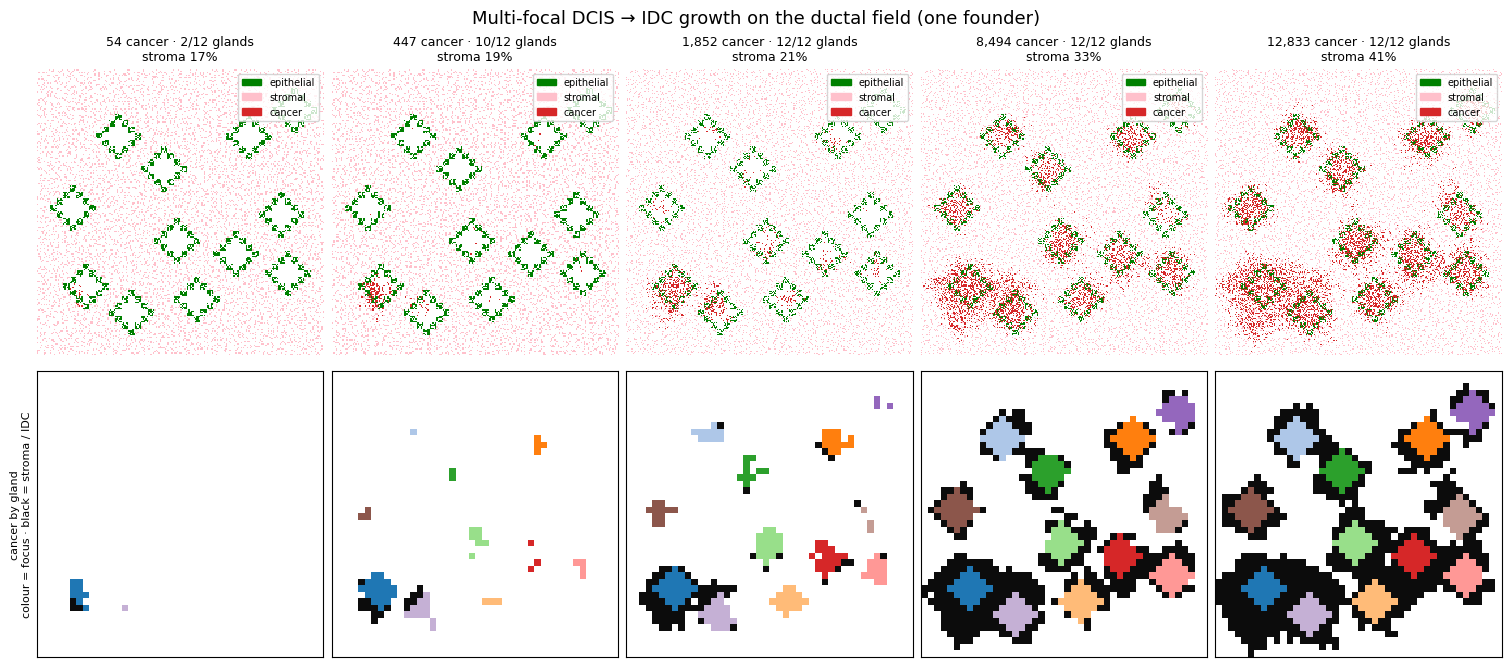

In [3]:
MILESTONES = [40, 400, 1500, 5000, 10000]   # cancer-cell counts to snapshot (seeding -> final IDC)
tg = GenotypeTumor(seed=B.BASE_SEED, genome_params=B.GENOME, selection_params=B.SELECTION,
                   cancer_cell_params=B.CANCER, deme_params=B.DEME, spatial_params=B.SPATIAL,
                   expression_params=B.EXPR(), update_mode="tau", tau=1.0)
snaps, mi = [], 0
while mi < len(MILESTONES):
    ncan = B._n_cancer(tg)
    if ncan >= MILESTONES[mi]:
        tg.make_cell_data()
        snaps.append(dict(step=tg.step, ncan=ncan, ngl=len(B.glands_colonised(tg)),
                          stroma=B.stroma_cancer_pct(tg), cd=tg.cell_data,
                          gland_grid=B.cancer_gland_grid(tg)))
        mi += 1
        continue
    tg.grow(n_steps=(1 if ncan < 2500 else 2), seed=B.BASE_SEED)   # fine early so DCIS phase is caught

ncol = len(snaps)
fig, axes = plt.subplots(2, ncol, figsize=(3.0 * ncol, 6.6), constrained_layout=True)
gland_cmap = plt.get_cmap("tab20")
for k, s in enumerate(snaps):
    viz.plot_grid(s["cd"], tg.grid_size, tg.traces, tg.genotypes_parents, color=["cell_type"],
                  ax=axes[0, k], expand_demes=True, section_frac=0.4, cancer_color="#d62728")
    axes[0, k].set_title(f"{s['ncan']:,} cancer · {s['ngl']}/{tg.n_glands} glands\nstroma {s['stroma']:.0f}%",
                         fontsize=9)
    grid = s["gland_grid"]
    rgb = np.ones((*grid.shape, 3))
    for r in range(grid.shape[0]):
        for c in range(grid.shape[1]):
            v = grid[r, c]
            if np.isnan(v):
                continue
            rgb[r, c] = (0.05, 0.05, 0.05) if v < 0 else gland_cmap(int(v) % 20)[:3]
    axes[1, k].imshow(rgb, interpolation="nearest"); axes[1, k].set_xticks([]); axes[1, k].set_yticks([])
axes[0, 0].set_ylabel("tissue (cells)\ngreen wall · red cancer · pink stroma", fontsize=8)
axes[1, 0].set_ylabel("cancer by gland\ncolour = focus · black = stroma / IDC", fontsize=8)
fig.suptitle("Multi-focal DCIS → IDC growth on the ductal field (one founder)", fontsize=13)
print("snapshots (step, cancer, glands, stroma%):",
      [(s["step"], s["ncan"], s["ngl"], round(s["stroma"])) for s in snaps])

## 3. Clonal dynamics

The tumour is **infinite-sites**: most divisions spawn a new (passenger-differentiated) genotype, so
there are tens of thousands of clones. A raw Muller plot would hang; `min_freq` merges every clone whose
subtree never reaches that fraction of the population into its nearest ancestor (a Noble-style
sensitivity threshold). `by_drivers=True` collapses passenger diversity, colouring by distinct
**driver-mutation** combinations.

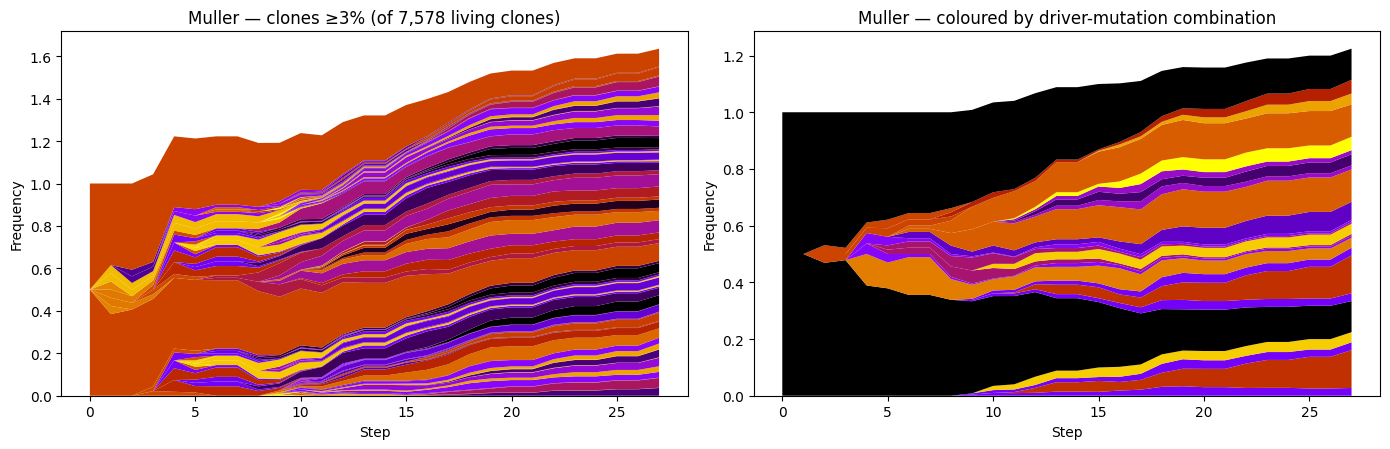

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
t.plot_muller(ax=axes[0], min_freq=0.03)
axes[0].set_title(f"Muller — clones ≥3% (of {living_clones:,} living clones)")
t.plot_muller(ax=axes[1], min_freq=0.03, by_drivers=True)
axes[1].set_title("Muller — coloured by driver-mutation combination")
plt.tight_layout()

## 4. The ground-truth matrices

The per-cell matrices in `cell_data` are what every downstream notebook reads. Ordered normal-then-
cancer, the structure is already visible: **SNVs** accumulate in malignant cells, **copy number**
departs from the diploid (CN = 2) normal baseline, and **expression** carries both the copy-number
dosage and the gene-program signal. Two ductal-field additions ride alongside: `cell_gland` (the focus
each cell sits in) and the compartment traits in `cell_evo` (`breach`, `stromal_survival`).

dashed line = normal/cancer split;  cell_data keys: ['cell_evo', 'cell_snv', 'cell_cnv', 'cell_exp', 'cell_crd', 'cell_type', 'cell_deme', 'cell_rna_vaf', 'cell_wgd', 'cell_gland', 'cell_exp_p', 'cell_exp_m', 'cell_rna_baf', 'cell_program']
compartment traits (cancer): breach mean 0.87 · stromal_survival mean 0.79  (both ≈0 in normal cells)


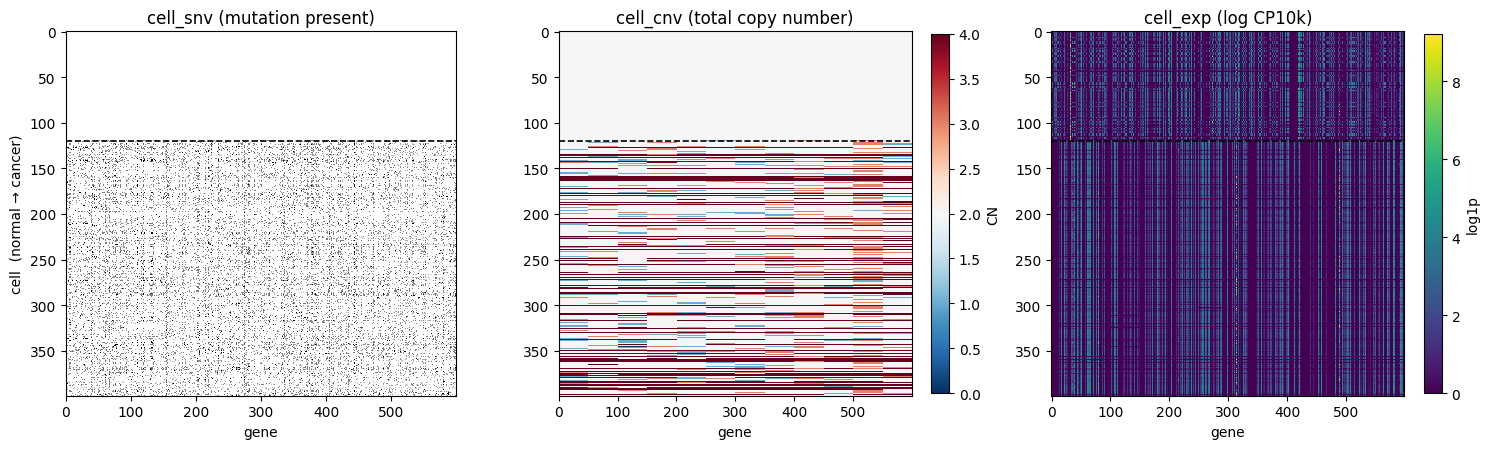

In [5]:
rng = np.random.default_rng(0)
order = np.concatenate([rng.permutation(np.where(~cancer)[0])[:120],
                        rng.permutation(np.where(cancer)[0])[:280]])
split = 120

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
axes[0].imshow(cd["cell_snv"].values[order], aspect="auto", cmap="binary", interpolation="none")
axes[0].set_title("cell_snv (mutation present)"); axes[0].set_xlabel("gene")
axes[0].set_ylabel("cell  (normal → cancer)")

im1 = axes[1].imshow(cd["cell_cnv"].values[order], aspect="auto", cmap="RdBu_r", vmin=0, vmax=4,
                     interpolation="none")
axes[1].set_title("cell_cnv (total copy number)"); axes[1].set_xlabel("gene")
plt.colorbar(im1, ax=axes[1], fraction=0.046, label="CN")

E = cd["cell_exp"].values[order]
im2 = axes[2].imshow(np.log1p(E / E.sum(1, keepdims=True) * 1e4), aspect="auto", cmap="viridis",
                     interpolation="none")
axes[2].set_title("cell_exp (log CP10k)"); axes[2].set_xlabel("gene")
plt.colorbar(im2, ax=axes[2], fraction=0.046, label="log1p")
for ax_ in axes:
    ax_.axhline(split, color="k", lw=1.2, ls="--")
plt.tight_layout()
print("dashed line = normal/cancer split;  cell_data keys:", list(cd.keys()))
br = B.cell_trait(t, "breach"); ss = B.cell_trait(t, "stromal_survival")
print(f"compartment traits (cancer): breach mean {br[cancer].mean():.2f} · "
      f"stromal_survival mean {ss[cancer].mean():.2f}  (both ≈0 in normal cells)")

## 5. What each notebook uses

| notebook | reads | recovers (scored vs iscc ground truth) |
|---|---|---|
| [`compartment_selection_confound`](compartment_selection_confound.ipynb) | `cell_gland`, `cell_evo`, `cell_program`, `microenv_truth` | the DCIS→IDC transition + the genetic-vs-niche emt confound |
| [`combining_scdna_scrna`](combining_scdna_scrna.ipynb) | `cell_cnv`, `cell_exp` (scDNA + scRNA) | subclones from RNA via DNA-defined CN profiles (clonealign idea) |
| [`wgd_allele_cna`](wgd_allele_cna.ipynb) | `cell_wgd`, allele CN, `cell_rna_baf` | which copy-number states are allele-only detectable, and the WGD ploidy signature |
| [`gene_programs`](gene_programs.ipynb) | `cell_program`, `cell_exp`, `program_truth` | expression programs vs the contiguous-CNA confound (NMF); the emt genetic+niche arms |
| [`tree_inference_dna`](tree_inference_dna.ipynb) | `cell_snv`, `cell_gland`, `genotypes_parents` | the clonal phylogeny + the inter-gland spread tree (phylogeography) |
| [`scrna_visium_integration`](scrna_visium_integration.ipynb) | Visium spots + scRNA reference | per-spot cell-type composition across foci by NNLS deconvolution |
| [`cohort_shared_programs`](cohort_shared_programs.ipynb) | 5 tumours (shared landscape) | programs shared across patients despite batch effects (scDEF / NMF) |
| [`cohort_mhn_recurrence`](cohort_mhn_recurrence.ipynb) | 5 tumours, driver events | recurrent mutations + their interactions/order (MHN / TreeMHN) |

**Next:** open any notebook above — each starts with the same `import base_sim` and
`grow_base_tumor()`. The mechanics live in [`01_pipeline_walkthrough`](01_pipeline_walkthrough.ipynb),
[`03_data_overview`](03_data_overview.ipynb) and the [`assay_*`](assay_scrna.ipynb) notebooks; the
production-tool benchmarks and the full ductal-field / compartment validations live under `validation/`
(`validate_ductal_field.py`, `validate_compartment_selection.py`).